<a href="https://colab.research.google.com/github/carolembomegni/Projet_SD_Detection_Tumeurs/blob/Angele-Projet/Entrainement_Model_MobileNetV2%2C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import gdown
import zipfile
import os

file_id = "1PIRDtyfUM3prHQKm_tdfw_-5bGeVDJTc"
url = f"https://drive.google.com/uc?id={file_id}"

output = "dataset.zip"

gdown.download(url, output, quiet=False)

with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall("/content/")

# Détection du dossier dataset
possible_dirs = [d for d in os.listdir("/content") if "brain" in d.lower()]

if len(possible_dirs) > 0:
    DATA_PATH = f"/content/{possible_dirs[0]}"
else:
    raise Exception("Dataset folder not found")

print("DATA_PATH =", DATA_PATH)

Downloading...
From (original): https://drive.google.com/uc?id=1PIRDtyfUM3prHQKm_tdfw_-5bGeVDJTc
From (redirected): https://drive.google.com/uc?id=1PIRDtyfUM3prHQKm_tdfw_-5bGeVDJTc&confirm=t&uuid=7298486c-8221-4612-8b6e-9ece2c005ef3
To: /content/dataset.zip
100%|██████████| 94.3M/94.3M [00:02<00:00, 36.7MB/s]


DATA_PATH = /content/brain-tumor-classification-mri


In [2]:
import os

import shutil

from pathlib import Path

# =====================================

# CHEMINS

# =====================================

src_root = Path(DATA_PATH)      # chemin détecté automatiquement par le bloc d'import

dst_root = Path("/content/Binary")

splits = ["Training", "Testing"]

tumor_folders = ["glioma_tumor", "meningioma_tumor", "pituitary_tumor"]

no_tumor_folder = "no_tumor"

# =====================================

# NETTOYAGE SI LE DOSSIER EXISTE DEJA

# =====================================

if dst_root.exists():

    shutil.rmtree(dst_root)

# =====================================

# CREATION DES DOSSIERS DE DESTINATION

# =====================================

for split in splits:

    (dst_root / split / "tumor").mkdir(parents=True, exist_ok=True)

    (dst_root / split / "no_tumor").mkdir(parents=True, exist_ok=True)

# =====================================

# FONCTION DE COPIE SECURISEE

# =====================================

def safe_copy(src_file: Path, dst_dir: Path):

    dst_file = dst_dir / src_file.name

    if dst_file.exists():

        dst_file = dst_dir / f"{src_file.stem}_{abs(hash(str(src_file))) % 10**8}{src_file.suffix}"

    shutil.copy2(src_file, dst_file)

# =====================================

# FUSION DES CLASSES EN BINAIRE

# =====================================

for split in splits:

    # Fusion des classes tumor

    for cls in tumor_folders:

        cls_path = src_root / split / cls

        if cls_path.exists():

            for img in cls_path.rglob("*"):

                if img.is_file():

                    safe_copy(img, dst_root / split / "tumor")

    # Copie de la classe no_tumor

    cls_path = src_root / split / no_tumor_folder

    if cls_path.exists():

        for img in cls_path.rglob("*"):

            if img.is_file():

                safe_copy(img, dst_root / split / "no_tumor")

# =====================================

# VERIFICATION

# =====================================

print("✅ Fusion binaire terminée.")

print("Dossier source :", src_root)

print("\nTraining classes :", os.listdir(dst_root / "Training"))

print("Testing classes  :", os.listdir(dst_root / "Testing"))

print("\nNombre d'images Training/tumor    :", len(list((dst_root / "Training" / "tumor").glob("*"))))

print("Nombre d'images Training/no_tumor :", len(list((dst_root / "Training" / "no_tumor").glob("*"))))

print("Nombre d'images Testing/tumor     :", len(list((dst_root / "Testing" / "tumor").glob("*"))))

print("Nombre d'images Testing/no_tumor  :", len(list((dst_root / "Testing" / "no_tumor").glob("*"))))




✅ Fusion binaire terminée.
Dossier source : /content/brain-tumor-classification-mri

Training classes : ['no_tumor', 'tumor']
Testing classes  : ['no_tumor', 'tumor']

Nombre d'images Training/tumor    : 2475
Nombre d'images Training/no_tumor : 395
Nombre d'images Testing/tumor     : 289
Nombre d'images Testing/no_tumor  : 105


In [3]:
import tensorflow as tf

import os

# ==============================

# CHEMINS DU DATASET BINAIRE

# ==============================

train_dir = "/content/Binary/Training"

test_dir  = "/content/Binary/Testing"

print("Classes train :", os.listdir(train_dir))

print("Classes test  :", os.listdir(test_dir))

# ==============================

# CHARGEMENT DU DATASET TRAIN

# ==============================

train_ds = tf.keras.utils.image_dataset_from_directory(

    train_dir,

    image_size=(224, 224),

    batch_size=32,

    label_mode='binary',

    shuffle=True,

    seed=42

)

# ==============================

# CHARGEMENT DU DATASET TEST

# ==============================

test_ds = tf.keras.utils.image_dataset_from_directory(

    test_dir,

    image_size=(224, 224),

    batch_size=32,

    label_mode='binary',

    shuffle=False

)

Classes train : ['no_tumor', 'tumor']
Classes test  : ['no_tumor', 'tumor']
Found 2870 files belonging to 2 classes.
Found 394 files belonging to 2 classes.


In [4]:
from PIL import Image
from pathlib import Path

# ==============================
# CHEMINS DU DATASET BINAIRE
# ==============================
train_dir = Path("/content/Binary/Training")
test_dir  = Path("/content/Binary/Testing")

# ==============================
# FONCTION SUPPRESSION IMAGES CORROMPUES
# ==============================
def remove_corrupted_images(folder):
    removed = 0
    for img_path in folder.rglob("*"):
        if img_path.is_file():
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except Exception:
                print("❌ Image corrompue supprimée :", img_path)
                img_path.unlink()
                removed += 1
    return removed

# ==============================
# EXECUTION
# ==============================
removed_train = remove_corrupted_images(train_dir)
removed_test  = remove_corrupted_images(test_dir)

print("\n✅ Nettoyage terminé")
print("Images supprimées - Training :", removed_train)
print("Images supprimées - Testing  :", removed_test)


✅ Nettoyage terminé
Images supprimées - Training : 0
Images supprimées - Testing  : 0


In [5]:
# Equilibrer le data  d entrainement

import shutil

import numpy as np

from pathlib import Path

from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, save_img

# =====================================

# DOSSIERS SOURCE

# =====================================

train_no = Path("/content/Binary/Training/no_tumor")

train_tu = Path("/content/Binary/Training/tumor")

# =====================================

# DOSSIERS DESTINATION EQUILIBRES

# =====================================

balanced_root = Path("/content/Binary/Training_balanced")

balanced_no = balanced_root / "no_tumor"

balanced_tu = balanced_root / "tumor"

# Nettoyage si le dossier existe déjà

if balanced_root.exists():

    shutil.rmtree(balanced_root)

balanced_no.mkdir(parents=True, exist_ok=True)

balanced_tu.mkdir(parents=True, exist_ok=True)

# =====================================

# LISTE DES IMAGES

# =====================================

no_files = list(train_no.glob("*"))

tu_files = list(train_tu.glob("*"))

n_no = len(no_files)

n_tu = len(tu_files)

print("Nombre initial no_tumor :", n_no)

print("Nombre initial tumor    :", n_tu)

# =====================================

# COPIE DES IMAGES ORIGINALES

# =====================================

for f in no_files:

    shutil.copy2(f, balanced_no / f.name)

for f in tu_files:

    shutil.copy2(f, balanced_tu / f.name)

# =====================================

# DATA AUGMENTATION

# =====================================

datagen = ImageDataGenerator(

    rotation_range=20,

    width_shift_range=0.10,

    height_shift_range=0.10,

    zoom_range=0.10,

    horizontal_flip=True,

    fill_mode='nearest'

)

# =====================================

# FONCTION POUR GENERER JUSQU'A EQUILIBRE

# =====================================

def augment_until_target(files, output_dir, target_count, prefix):

    current_count = len(list(output_dir.glob("*")))

    i = 0

    while current_count < target_count:

        img_path = files[i % len(files)]

        img = load_img(img_path, target_size=(224, 224))

        x = img_to_array(img)

        x = np.expand_dims(x, axis=0)

        aug_iter = datagen.flow(x, batch_size=1)

        aug_img = next(aug_iter)[0].astype("uint8")

        save_path = output_dir / f"{prefix}_aug_{current_count}.jpg"

        save_img(save_path, aug_img)

        current_count += 1

        i += 1

# =====================================

# EQUILIBRAGE

# =====================================

target = max(n_no, n_tu)

if n_no < target:

    augment_until_target(no_files, balanced_no, target, "no_tumor")

if n_tu < target:

    augment_until_target(tu_files, balanced_tu, target, "tumor")

print("\n✅ Equilibrage terminé")

print("no_tumor final :", len(list(balanced_no.glob('*'))))

print("tumor final    :", len(list(balanced_tu.glob('*'))))


Nombre initial no_tumor : 395
Nombre initial tumor    : 2475

✅ Equilibrage terminé
no_tumor final : 2475
tumor final    : 2475


In [6]:
# Charger le ytrain equilibre plus test
import tensorflow as tf
import os

balanced_train_dir = "/content/Binary/Training_balanced"
test_dir = "/content/Binary/Testing"

print("Classes train équilibré :", os.listdir(balanced_train_dir))
print("Classes test            :", os.listdir(test_dir))

Classes train équilibré : ['no_tumor', 'tumor']
Classes test            : ['no_tumor', 'tumor']


In [7]:
# Créer train et validation à partir du train équilibré
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    balanced_train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    balanced_train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=True
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False
)

print("Noms des classes :", train_ds.class_names)

Found 4950 files belonging to 2 classes.
Using 3960 files for training.
Found 4950 files belonging to 2 classes.
Using 990 files for validation.
Found 394 files belonging to 2 classes.
Noms des classes : ['no_tumor', 'tumor']


In [8]:
# Normalisation
import tensorflow as tf

AUTOTUNE = tf.data.AUTOTUNE

# ==============================
# COUCHE DE NORMALISATION
# ==============================
normalization_layer = tf.keras.layers.Rescaling(1./255)

# ==============================
# APPLICATION SUR LES DATASETS
# ==============================
train_ds = train_ds.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=AUTOTUNE
)

val_ds = val_ds.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=AUTOTUNE
)

test_ds = test_ds.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=AUTOTUNE
)

# ==============================
# OPTIMISATION DU PIPELINE
# ==============================
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("✅ Normalisation terminée (pixels entre 0 et 1)")

✅ Normalisation terminée (pixels entre 0 et 1)


/tmp/ipykernel_13112/2786853809.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(f"Label: {int(labels[i].numpy())}")


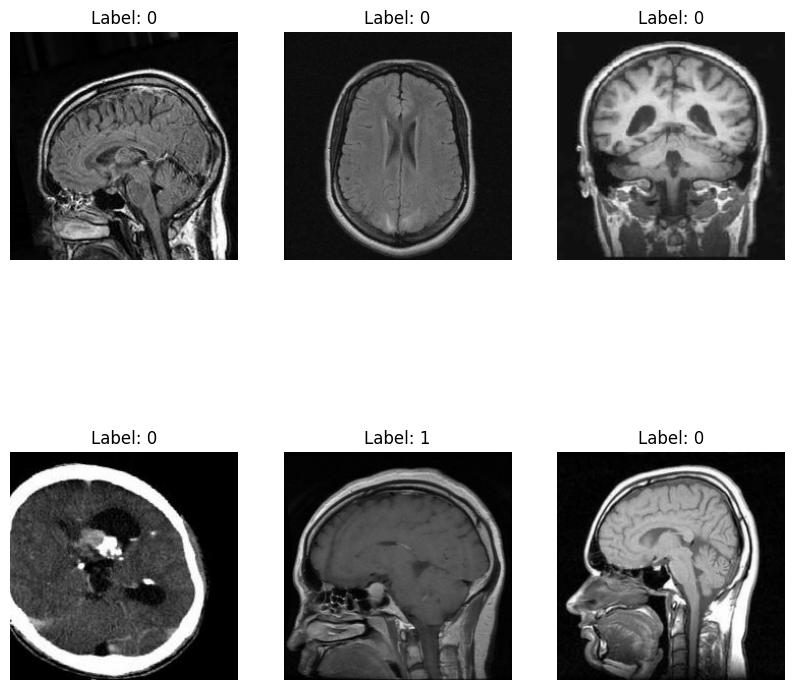

In [9]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 10))
    for i in range(6):
        ax = plt.subplot(2, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(f"Label: {int(labels[i].numpy())}")
        plt.axis("off")
    plt.show()

In [10]:
# Nettoyer la memoire
import tensorflow as tf
from tensorflow.keras import backend as K
import gc

K.clear_session()
gc.collect()


0

In [11]:
# recharger les data
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/Binary/Training_balanced",
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/Binary/Training_balanced",
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/Binary/Testing",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

print("Classes :", train_ds.class_names)

# Sauvegarde des classes
class_names = train_ds.class_names

Found 4950 files belonging to 2 classes.
Using 3960 files for training.
Found 4950 files belonging to 2 classes.
Using 990 files for validation.
Found 394 files belonging to 2 classes.
Classes : ['no_tumor', 'tumor']


In [12]:
#Optimiser le pipeline
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.prefetch(buffer_size=AUTOTUNE)

## **MobileNetV2**

In [13]:
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Base MobileNetV2
base_model = MobileNetV2(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

# Modèle complet
inputs = layers.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = preprocess_input(x)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,201 (9.26 MB)

 Trainable params: 166,657 (651.00 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [14]:
#Compilation
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [15]:
# Callsbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1),
    ModelCheckpoint("/content/mobilenetv2_best.keras", save_best_only=True)
]

In [16]:
#Entraînement sans class_weight
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 22s 100ms/step - accuracy: 0.8207 - loss: 0.3989 - val_accuracy: 0.9253 - val_loss: 0.1832 - learning_rate: 1.0000e-04
Epoch 2/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 10s 79ms/step - accuracy: 0.9293 - loss: 0.1953 - val_accuracy: 0.9495 - val_loss: 0.1333 - learning_rate: 1.0000e-04
Epoch 3/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 11s 86ms/step - accuracy: 0.9364 - loss: 0.1726 - val_accuracy: 0.9586 - val_loss: 0.1181 - learning_rate: 1.0000e-04
Epoch 4/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 11s 87ms/step - accuracy: 0.9465 - loss: 0.1525 - val_accuracy: 0.9606 - val_loss: 0.1055 - learning_rate: 1.0000e-04
Epoch 5/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 10s 81ms/step - accuracy: 0.9561 - loss: 0.1234 - val_accuracy: 0.9667 - val_loss: 0.1015 - learning_rate: 1.0000e-04
Epoch 6/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 10s 81ms/step - accuracy: 0.9626 - loss: 0.1124 - val_accuracy: 0.9687 - val_loss: 0.0953 - learning_rate: 1.0000e-04
Epoch 7/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 10s 81ms/st

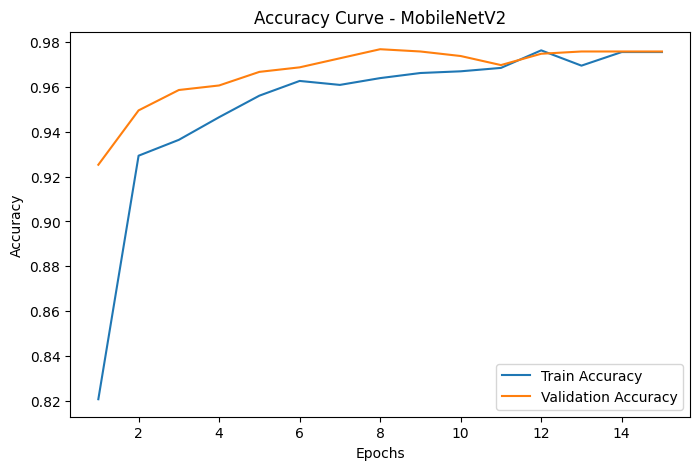

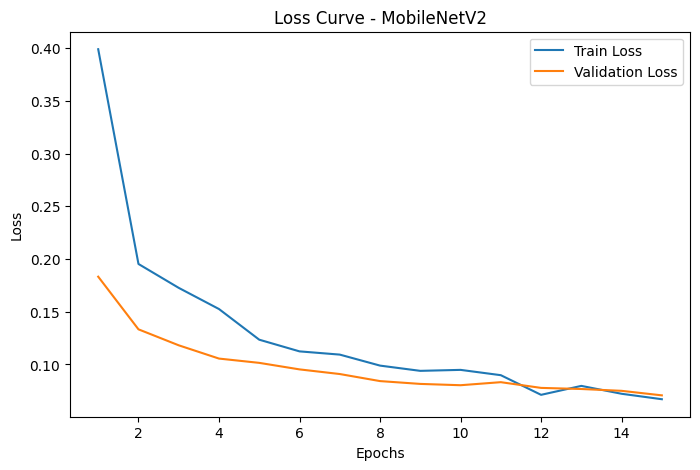

In [17]:
import matplotlib.pyplot as plt

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, acc, label="Train Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve - MobileNetV2")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, loss, label="Train Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve - MobileNetV2")
plt.legend()
plt.show()

In [18]:
# Evaluation
test_loss, test_acc = model.evaluate(test_ds)

print(f"Test Accuracy MobileNetV2 : {test_acc:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.8832 - loss: 0.3384
Test Accuracy MobileNetV2 : 0.8832


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step

===== Seuil = 0.5 =====
Precision tumor : 0.9840637450199203
Recall tumor    : 0.8546712802768166
F1-score tumor  : 0.9148148148148149
Matrice de confusion :
[[101   4]
 [ 42 247]]

===== Seuil = 0.4 =====
Precision tumor : 0.97265625
Recall tumor    : 0.8615916955017301
F1-score tumor  : 0.9137614678899083
Matrice de confusion :
[[ 98   7]
 [ 40 249]]

===== Seuil = 0.3 =====
Precision tumor : 0.9696969696969697
Recall tumor    : 0.8858131487889274
F1-score tumor  : 0.9258589511754068
Matrice de confusion :
[[ 97   8]
 [ 33 256]]

===== Seuil = 0.2 =====
Precision tumor : 0.9527272727272728
Recall tumor    : 0.9065743944636678
F1-score tumor  : 0.9290780141843972
Matrice de confusion :
[[ 92  13]
 [ 27 262]]

Meilleur seuil choisi : 0.2

Classification Report final :
              precision    recall  f1-score   support

    no_tumor       0.77      0.88      0.82       105
       tumor       0.95      0.91      0.93       289

    accuracy    

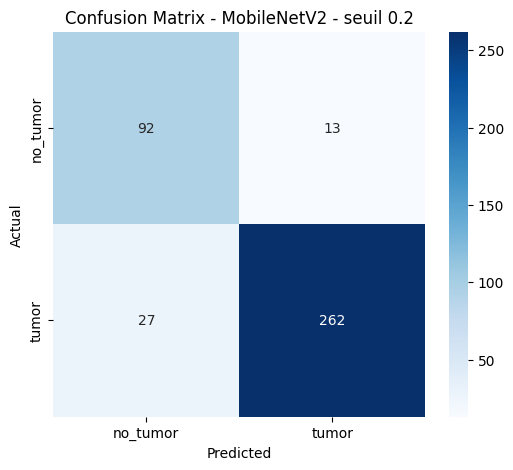

In [20]:
# Opimisation avec seuil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score

y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0)
y_prob = model.predict(test_ds).ravel()

thresholds = [0.5, 0.4, 0.3, 0.2]
results = []

for threshold in thresholds:
    y_pred = (y_prob > threshold).astype(int)

    precision = precision_score(y_true, y_pred, pos_label=1)
    recall = recall_score(y_true, y_pred, pos_label=1)
    f1 = f1_score(y_true, y_pred, pos_label=1)

    print(f"\n===== Seuil = {threshold} =====")
    print("Precision tumor :", precision)
    print("Recall tumor    :", recall)
    print("F1-score tumor  :", f1)
    print("Matrice de confusion :")
    print(confusion_matrix(y_true, y_pred))

    results.append((threshold, precision, recall, f1))

best_threshold = max(results, key=lambda x: x[3])[0]
print("\nMeilleur seuil choisi :", best_threshold)

y_pred_best = (y_prob > best_threshold).astype(int)

print("\nClassification Report final :")
print(classification_report(y_true, y_pred_best, target_names=class_names))

cm = confusion_matrix(y_true, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - MobileNetV2 - seuil {best_threshold}")
plt.show()

### Analyse des performances de MobileNetV2

Le modèle MobileNetV2 a montré une très bonne capacité d’apprentissage sur le jeu d’entraînement augmenté, avec une progression régulière de l’accuracy et une diminution continue de la loss sur l’ensemble de validation. Les courbes obtenues ne montrent pas de surapprentissage marqué, ce qui suggère une bonne généralisation du modèle.

Avec le seuil par défaut de 0.5, le modèle obtient une accuracy de test de 88.32 %. Une optimisation du seuil de décision a ensuite été réalisée afin d’améliorer le compromis entre précision et rappel pour la classe `tumor`.

Le meilleur résultat a été obtenu avec un seuil de 0.2, donnant un F1-score de 0.93 pour la classe `tumor`, avec une précision de 0.95 et un rappel de 0.91. Cela signifie que le modèle détecte correctement la majorité des cas tumoraux, ce qui est particulièrement important dans un contexte médical.

La classe `no_tumor` présente des performances plus modestes (F1-score de 0.82), ce qui indique que le modèle tend davantage à prédire la présence d’une tumeur lorsque le seuil est abaissé. Ce comportement augmente légèrement le nombre de faux positifs, mais permet de réduire le risque de faux négatifs, qui sont plus critiques pour ce type d’application.